In [1]:
import importlib.util, subprocess, sys

_pkgs = ["langgraph", "langchain_community", "langchain_openai", "langsmith", "langgraph-supervisor"]
_missing = [p for p in _pkgs if importlib.util.find_spec(p.replace("-", "_").split("[")[0]) is None]
if _missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + _pkgs)

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Environment Variable Initialization

import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())  # loads .env from the notebook's working directory

def _set_if_undefined(var_name: str):
    value = os.environ.get(var_name, "").strip()
    if value:
        masked = value[:6] + "*" * (min(20, len(value) - 6))
        print(f"  ✅ {var_name}: {masked}")
    else:
        print(f"  ❌ {var_name}: not set")

# ---- Environment Variables Required ----

print("Checking environment variables...")
_set_if_undefined("OPENAI_API_KEY")         # API key for OpenAI models
_set_if_undefined("LANGSMITH_TRACING")      # Enable LangSmith tracing ("true" to enable)
_set_if_undefined("LANGSMITH_API_KEY")      # https://docs.langchain.com/langsmith/observability
_set_if_undefined("OPENAI_MODEL")           # e.g., "gpt-4.1", "gpt-4o", "gpt-4o-mini"
print("Done.")

Checking environment variables...
  ✅ OPENAI_API_KEY: sk-pro********************
  ✅ LANGSMITH_TRACING: true
  ✅ LANGSMITH_API_KEY: lsv2_p********************
  ✅ OPENAI_MODEL: gpt-4o*****
Done.


In [3]:
# Multi-Agent Orchestration with LangGraph:
#- Supervisor agent coordinates between specialized workers.
#- Workers: dressing planner agents.
# ---- Imports ----
import os, warnings
from langchain_openai import ChatOpenAI
from langgraph_supervisor import create_supervisor
from langgraph.prebuilt import create_react_agent
from langgraph.warnings import LangGraphDeprecatedSinceV10

# Silence the create_react_agent V1.0 deprecation warning so demo output is clean.
warnings.filterwarnings("ignore", category=LangGraphDeprecatedSinceV10)

# ---- LLM Setup ----

# Load the default model from environment variables
default_model = os.environ["OPENAI_MODEL"]

# Initialize the LLM (Large Language Model) interface
llm = ChatOpenAI(model=default_model)

# ---- Node Definitions ----

# Dressing Planner Agent
adults_dressing_planner_agent = create_react_agent(
    llm,
    tools=[],
    name="adults_dressing_planner_agent",
    prompt=(
        "You suggest dressing options for adults based on the current weather and UV index. "
        "Prioritize UV index, 'feels like' temperature and consider wind conditions."
    )
)

# Dressing Planner Agent
childrens_dressing_planner_agent = create_react_agent(
    llm,
    tools=[],
    name="childrens_dressing_planner_agent",
    prompt=(
        "You suggest dressing options for children based on the current weather and UV index. "
        "Prioritize UV index, 'feels like' temperature and consider wind conditions."
    )
)

# ---- Supervisor Setup ----


# System prompt guiding the supervisor's behavior
dressing_system_prompt = (
    "# Role and Objective"
    "You are a Supervisor Agent tasked with managing a conversation between multiple specialized workers: "
    "`adults_dressing_planner_agent`, and `childrens_dressing_planner_agent`."
    "Your goal is to suggest dressing options based on the weather, UV index and persons age"
    "orchestrate worker actions to resolve the user's request efficiently."
    "# Instructions"
    " - Persist through multiple steps until the task is fully complete."
    " - Always select the next worker based on context."
    " - Think step-by-step before choosing a worker and after receiving results."
    "# Reasoning Steps"
    "1. Analyze current state."
    "2. Plan the next best action."
    "3. Reflect after worker output."
    "4. Repeat until completion."
    "# Tool/Worker Use"
    "- `adults_dressing_planner_agent`: suggest clothing for adults based on the weather and UV index"
    "- `childrens_dressing_planner_agent`: suggest clothing for children based on the weather and UV index"
)

# Create supervisor
dressing_supervisor = create_supervisor(
    agents=[adults_dressing_planner_agent, childrens_dressing_planner_agent],
    model=llm,
    prompt=(dressing_system_prompt),
    supervisor_name="dressing_supervisor"
)

dressing_team = dressing_supervisor.compile(name="dressing_team")


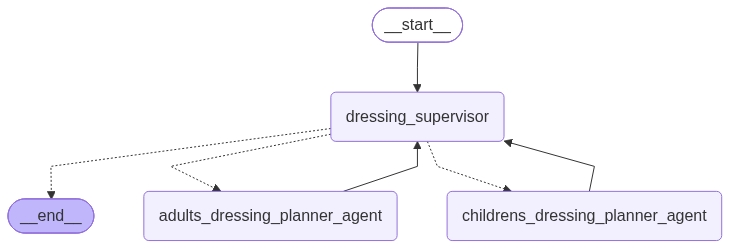

In [4]:
from IPython.display import display, Image
display(Image(dressing_team.get_graph().draw_mermaid_png()))

In [5]:

for s in dressing_team.stream(
    {"messages": [("user", "The Stockholm weather forecast for today indicates mostly light rain showers with a gentle breeze. UV index is 3, and we are family of 3, a 5 year old child, a 40 year old father and a 90 year old grand mother")]}, debug=True):
    print(s)
    print("============================")

[values] {'messages': [HumanMessage(content='The Stockholm weather forecast for today indicates mostly light rain showers with a gentle breeze. UV index is 3, and we are family of 3, a 5 year old child, a 40 year old father and a 90 year old grand mother', additional_kwargs={}, response_metadata={}, id='fdbfaa2e-91dd-41e0-95a2-5021b35f0e08')]}
[updates] {'dressing_supervisor': {'messages': [HumanMessage(content='The Stockholm weather forecast for today indicates mostly light rain showers with a gentle breeze. UV index is 3, and we are family of 3, a 5 year old child, a 40 year old father and a 90 year old grand mother', additional_kwargs={}, response_metadata={}, id='fdbfaa2e-91dd-41e0-95a2-5021b35f0e08'), AIMessage(content="Let's start by addressing the clothing suggestions for the adults and then for the child. I'll first consult the `adults_dressing_planner_agent` for the father and grandmother's clothing suggestions. \n\nI'll proceed with that now.", additional_kwargs={'refusal': N